In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [2]:
import cv2
img =cv2.imread(r"E:\Full Stack data science\Image Processing\PetImages\Cat\1.jpg")

In [3]:
img.shape

(281, 300, 3)

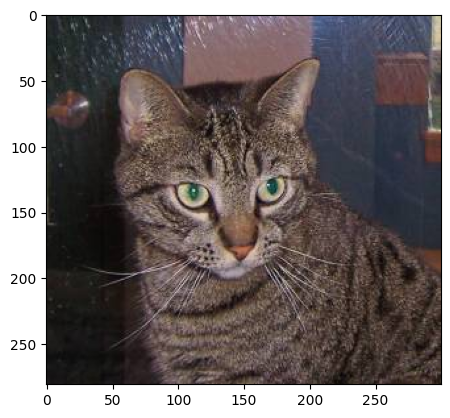

In [4]:
from matplotlib import pyplot as plt
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [5]:
IMAGE_WIDTH = img.shape[0]
IMAGE_HEIGHT = img.shape[1]
IMAGE_SIZE = [IMAGE_WIDTH, IMAGE_HEIGHT]
IMAGE_CHANNELS = 3
IMAGE_SIZE=(150,150)


## loading data from file

In [6]:
import os
import pathlib
baseDir = "PetImages"
filenames = os.listdir("PetImages")
categories = []
filename = []

for file in filenames:
    subdir = os.path.join(baseDir,file)
    for i in os.listdir(subdir):
        if file == 'Dog':
            categories.append(1)
            filename.append(os.path.join(subdir,i))
        else:
            categories.append(0)
            filename.append(os.path.join(subdir,i))



In [7]:
import pandas as pd
df = pd.DataFrame({
    'filename':filename,
    'class':categories
})

In [8]:
df

,filename,class
0,PetImages\Cat\0.jpg,0
1,PetImages\Cat\1.jpg,0
2,PetImages\Cat\10.jpg,0
3,PetImages\Cat\100.jpg,0
4,PetImages\Cat\1000.jpg,0
...,...,...
24956,PetImages\Dog\9996.jpg,1
24957,PetImages\Dog\9997.jpg,1
24958,PetImages\Dog\9998.jpg,1
24959,PetImages\Dog\9999.jpg,1


<Axes: xlabel='class'>

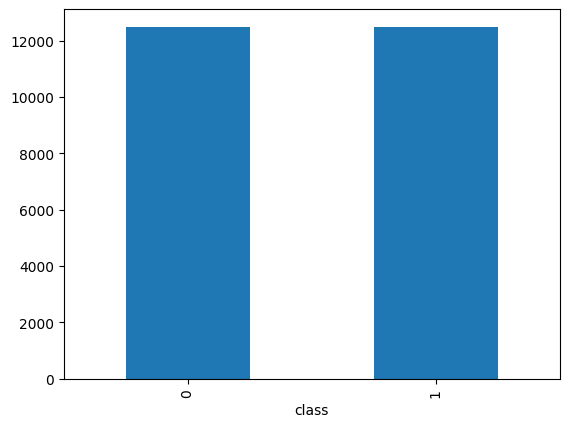

In [9]:
df['class'].value_counts().plot.bar()

# viewing images

(375, 500, 3)


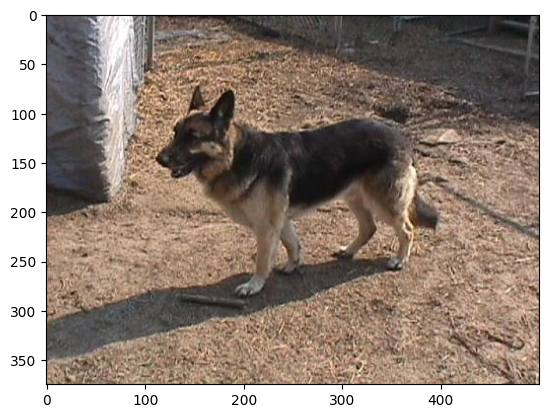

In [10]:
import numpy as np
sample = df["filename"].sample(n=1).tolist()[0]
img = cv2.imread(sample)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print(img.shape)
plt.imshow(img)

## Loading the images

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

batch_size = 32
IMAGE_SIZE = (224, 224)

# Split automatically into train + validation
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2   # 80% train, 20% validation
)

# TRAIN generator
train_generator = datagen.flow_from_directory(
    "petImages",
    target_size=IMAGE_SIZE,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# VALIDATION generator
valid_generator = datagen.flow_from_directory(
    "petImages",
    target_size=IMAGE_SIZE,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 19968 images belonging to 2 classes.
Found 4991 images belonging to 2 classes.


In [12]:
train_generator.image_shape

(224, 224, 3)

## chossing the model

In [13]:
from keras.models import Sequential
from tensorflow import keras
from keras.layers import Conv2D,MaxPooling2D,Dropout,Flatten,Dense,Activation

model = Sequential()
model.add(Conv2D(16,(3,3),activation='relu',input_shape=train_generator.image_shape))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(128,activation='relu'))

model.add(Dense(2,activation='softmax'))

opt = keras.optimizers.Adam(learning_rate=0.005)
model.compile(
    loss='categorical_crossentropy',
    optimizer=opt,
    metrics=['accuracy']   # ✅ corrected
)

In [14]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   


 conv2d (Conv2D)             (None, 222, 222, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 16)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 32)      4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 54, 54, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 64)        18496     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 26, 26, 64)        0         
 g2D)                                                            
                                                                 
 flatten (

## Split our dataset

In [15]:
train_df, validate_df = train_test_split(df,test_size=0.20,random_state=7)
train_df = train_df.reset_index(drop=True)
validate_df = validate_df.reset_index(drop=True)

In [16]:
train_df

,filename,class
0,PetImages\Cat\1248.jpg,0
1,PetImages\Dog\5281.jpg,1
2,PetImages\Dog\5972.jpg,1
3,PetImages\Cat\8314.jpg,0
4,PetImages\Cat\1605.jpg,0
...,...,...
19963,PetImages\Cat\10827.jpg,0
19964,PetImages\Dog\6146.jpg,1
19965,PetImages\Cat\3881.jpg,0
19966,PetImages\Cat\8423.jpg,0


In [17]:
validate_df.head()

,filename,class
0,PetImages\Dog\4759.jpg,1
1,PetImages\Cat\2035.jpg,0
2,PetImages\Cat\12009.jpg,0
3,PetImages\Cat\9183.jpg,0
4,PetImages\Cat\7059.jpg,0


## training the model

In [18]:
print(train_generator.image_shape)

(224, 224, 3)


In [ ]:
epochs = 3

history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=valid_generator
)

Epoch 1/3
 75/624 [==>...........................] - ETA: 23:01 - loss: 2.0236 - accuracy: 0.4812

e:\Full Stack data science\Image Processing\env\lib\site-packages\PIL\TiffImagePlugin.py:900: UserWarning: Truncated File Read
  warnings.warn(str(msg))


624/624 [==============================] - ETA: 0s - loss: 0.8534 - accuracy: 0.4953

In [ ]:
model.save_weights("cats_vs_dogs.h5")

## Get prediction on the validation datset

In [ ]:
predict = model.predict_generator(validation_generator, steps = np.ceil(5000/batch_size))

## Callback implementation

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
# Store weight at every epochs
checkpoint  = ModelCheckpoint("cats_vs_dogs_checkpoint.h5",
                              monitor='val_loss',
                              mode="min",
                              save_best_only= True,
                              verbose=1)

earlystop = EarlyStopping(monitor="val_loss",
                              min_delta= 0,
                              patience=5,
                              verbose=1,
                              restore_best_weights=True)

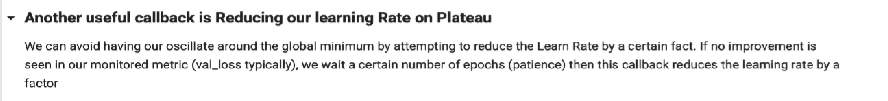

In [ ]:
from keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.2,
                              patience=3,
                              verbose=1,
                              min_delta=0.0001)

## adding all the callback in callback list

In [ ]:
callbacks = [earlystop, checkpoint, reduce_lr]

## Training the model again with callbacks

In [ ]:
epochs = 7

history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=valid_generator,
    callbacks=callbacks
)